# Module 20.1 Capstone: Early-Stage Wildfire Severity & Growth Prediction
**Research Question:** Can a machine learning model accurately predict the potential severity and growth of a wildfire based on its initial ignition and environmental conditions to optimize early emergency resource allocation?

## 1. Setup

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_curve, auc

sns.set_theme(style="ticks")

## 2. Load & Clean Data
Load the combined dataset

* Clean missing observations and duplicate records.
* Define high-severity fires as NWCG Size Classes **E, F, or G** ($\ge 300$ acres burned).

In [23]:
df_raw = pd.read_csv('data/FW_Veg_Rem_Combined.csv')

weather_cols = [
    'Temp_pre_30', 'Temp_pre_15', 'Temp_pre_7',
    'Wind_pre_30', 'Wind_pre_15', 'Wind_pre_7',
    'Hum_pre_30',  'Hum_pre_15',  'Hum_pre_7',
    'Prec_pre_30', 'Prec_pre_15', 'Prec_pre_7'
]
geo_cols = ['latitude', 'longitude', 'remoteness', 'Vegetation', 'discovery_month']
target_cols = ['fire_size', 'fire_size_class', 'fire_mag']

df = df_raw[weather_cols + geo_cols + target_cols].drop_duplicates().dropna().reset_index(drop=True)

# Parse month names/abbreviations to numbers
if df['discovery_month'].dtype == 'object':
    df['discovery_month'] = pd.to_datetime(df['discovery_month'], format='%b', errors='coerce').dt.month.fillna(pd.to_datetime(df['discovery_month'], format='%B', errors='coerce').dt.month)

df['is_high_severity'] = df['fire_size_class'].isin(['E', 'F', 'G']).astype(int)

print(f"Records: {len(df):,}")
print(f"High-severity rate: {df['is_high_severity'].mean():.2%}")

Records: 55,337
High-severity rate: 12.00%


## 3. Exploratory Data Analysis (EDA)
Checking wind trends, temp vs humidity, and correlation across the weather windows.

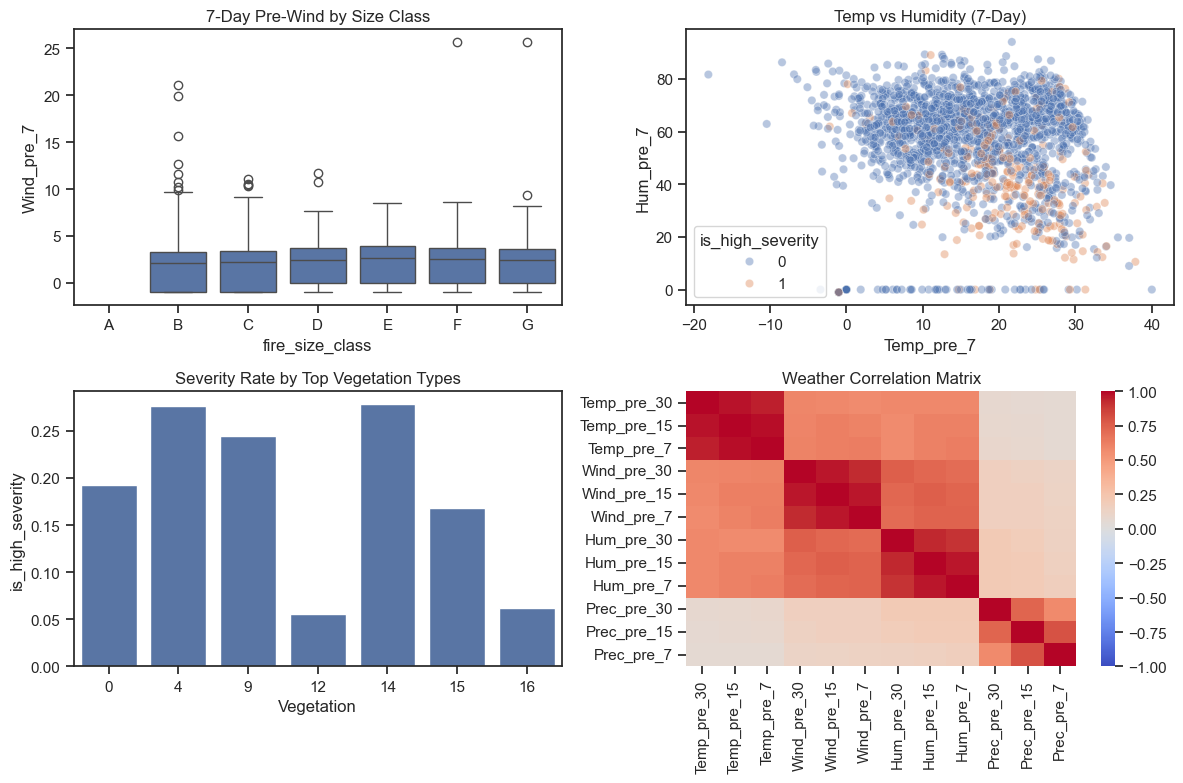

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x='fire_size_class', y='Wind_pre_7', ax=axes[0, 0], order=['A','B','C','D','E','F','G'])
axes[0, 0].set_title('7-Day Pre-Wind by Size Class')

sample = df.sample(n=min(3000, len(df)), random_state=42)
sns.scatterplot(data=sample, x='Temp_pre_7', y='Hum_pre_7', hue='is_high_severity', alpha=0.4, ax=axes[0, 1])
axes[0, 1].set_title('Temp vs Humidity (7-Day)')

top_veg = df['Vegetation'].value_counts().head(8).index
sns.barplot(data=df[df['Vegetation'].isin(top_veg)], x='Vegetation', y='is_high_severity', ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title('Severity Rate by Top Vegetation Types')

sns.heatmap(df[weather_cols].corr(), ax=axes[1, 1], cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 1].set_title('Weather Correlation Matrix')

plt.tight_layout()
plt.show()

## 4. PCA & Regional Clustering
The weather features are heavily correlated, so running PCA to reduce dimension and K-Means to pull out spatial/climate regions.

In [25]:
# PCA on weather
weather_scaled = StandardScaler().fit_transform(df[weather_cols])
pca = PCA(n_components=2, random_state=42)
pca_res = pca.fit_transform(weather_scaled)

df['weather_pc1'] = pca_res[:, 0]
df['weather_pc2'] = pca_res[:, 1]

# K-Means for regional clusters
geo_scaled = StandardScaler().fit_transform(df[['latitude', 'longitude', 'Temp_pre_30', 'Hum_pre_30']])
df['climate_zone'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(geo_scaled)

## 5. LASSO Coefficient Check
Quick sanity check using LassoCV on log fire size to see which features hold weight.

In [26]:
lasso_cols = weather_cols + ['latitude', 'longitude', 'remoteness', 'Vegetation', 'weather_pc1', 'weather_pc2']

X_lasso = StandardScaler().fit_transform(df[lasso_cols])
y_lasso = np.log1p(df['fire_size'])

lasso = LassoCV(cv=5, random_state=42).fit(X_lasso, y_lasso)
coefs = pd.Series(lasso.coef_, index=lasso_cols)

print(coefs[coefs != 0].sort_values(ascending=False))

Temp_pre_7     0.334488
Wind_pre_30    0.151843
Wind_pre_15    0.151808
latitude       0.120124
Prec_pre_15    0.004505
Prec_pre_30   -0.002129
Hum_pre_15    -0.036429
Temp_pre_15   -0.052360
Vegetation    -0.104716
Temp_pre_30   -0.107115
Hum_pre_30    -0.206970
Hum_pre_7     -0.208813
remoteness    -1.360528
longitude     -2.028008
dtype: float64


## 6. Baseline Model
Using a Logistic Regression with class weights to account for the imbalance.

In [27]:
features = weather_cols + ['latitude', 'longitude', 'remoteness', 'Vegetation', 'discovery_month', 'weather_pc1', 'climate_zone']

X = df[features].apply(pd.to_numeric, errors='coerce').dropna()
y = df.loc[X.index, 'is_high_severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_probs = clf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Standard', 'Severe']))

              precision    recall  f1-score   support

    Standard       0.96      0.81      0.88      9740
      Severe       0.35      0.78      0.49      1328

    accuracy                           0.80     11068
   macro avg       0.66      0.79      0.68     11068
weighted avg       0.89      0.80      0.83     11068



## 7. Model Evaluation
Evaluate model performance using Confusion Matrix and Precision-Recall metrics.

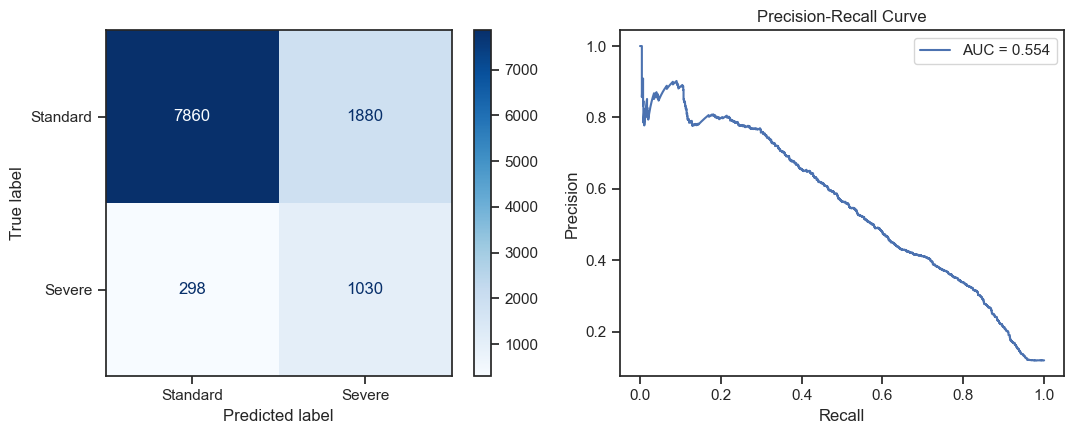

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Standard', 'Severe'], ax=ax1, cmap='Blues')

p, r, _ = precision_recall_curve(y_test, y_probs)
ax2.plot(r, p, label=f'AUC = {auc(r, p):.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.show()